Import the libraries.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


Read the data.

In [2]:
df = pd.read_csv('Datasets/placement.csv')
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


Plots.

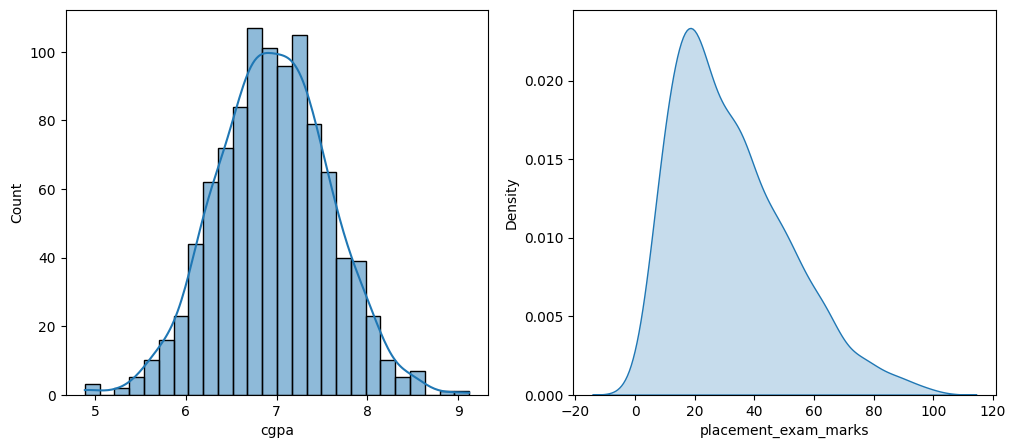

In [3]:
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(12,5))
sns.histplot(x='cgpa',data=df, ax=ax1, kde=True)
sns.kdeplot(x='placement_exam_marks',data=df, ax=ax2, fill=True)
plt.show()

In [4]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

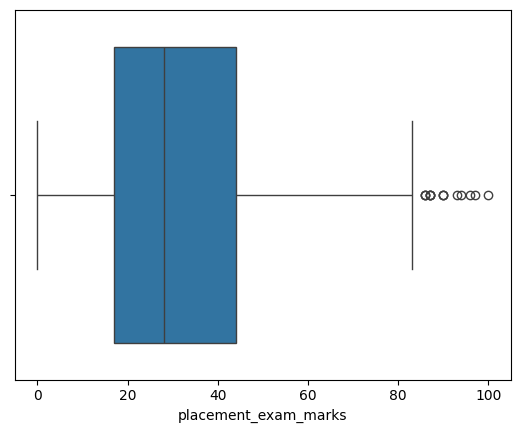

In [5]:
sns.boxplot(x='placement_exam_marks',data=df)
plt.show()

Find the 25,75 percentile and quantile range.

In [6]:
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)
iqr = percentile75 - percentile25
iqr

np.float64(27.0)

Find upper and lower limit.|

In [7]:
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr
print("Upper limit",upper_limit)
print("Lower limit",lower_limit)

Upper limit 84.5
Lower limit -23.5


In [8]:
df[df['placement_exam_marks'] > upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [9]:
df[df['placement_exam_marks'] < lower_limit]

,cgpa,placement_exam_marks,placed


Remove the outliers and take the data in the range only.

In [10]:
new_df = df[df['placement_exam_marks'] < upper_limit]
new_df.shape

(985, 3)

Comparision plot.

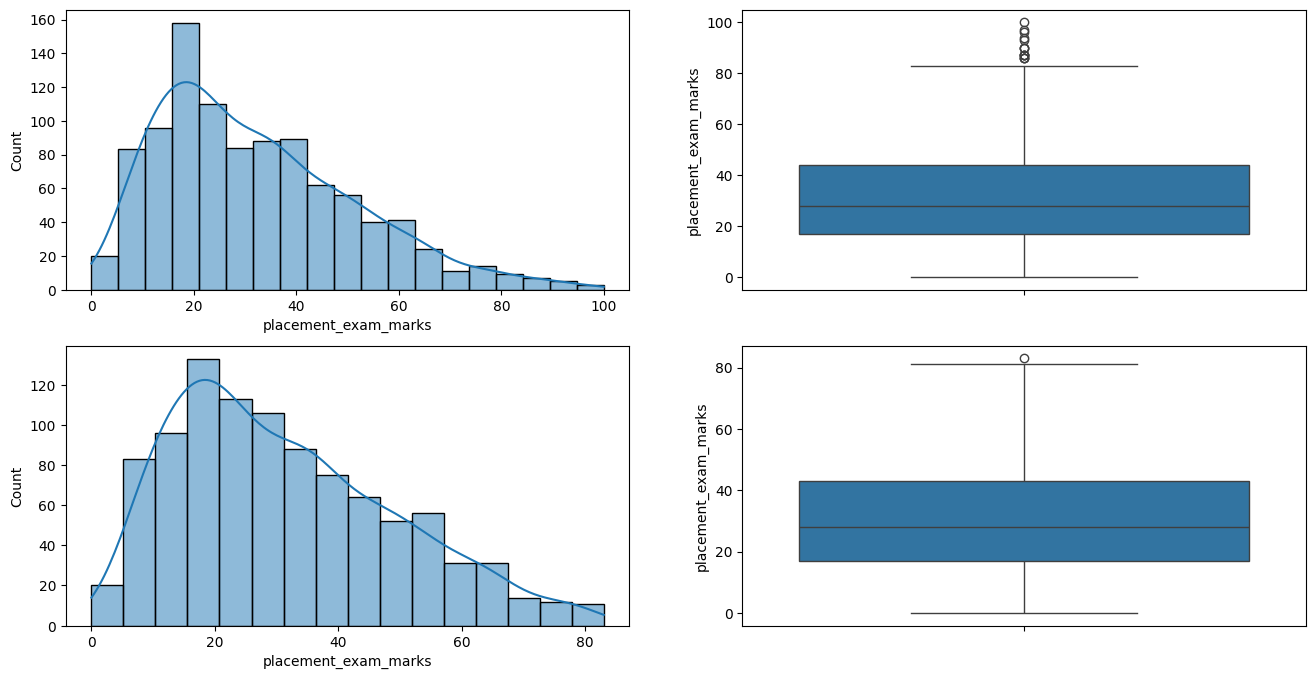

In [11]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.histplot(df['placement_exam_marks'], kde=True)

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.histplot(new_df['placement_exam_marks'], kde=True)

plt.subplot(2,2,4)
sns.boxplot(new_df['placement_exam_marks'])

plt.show()